# ``` Security, Governance, and Course Project```

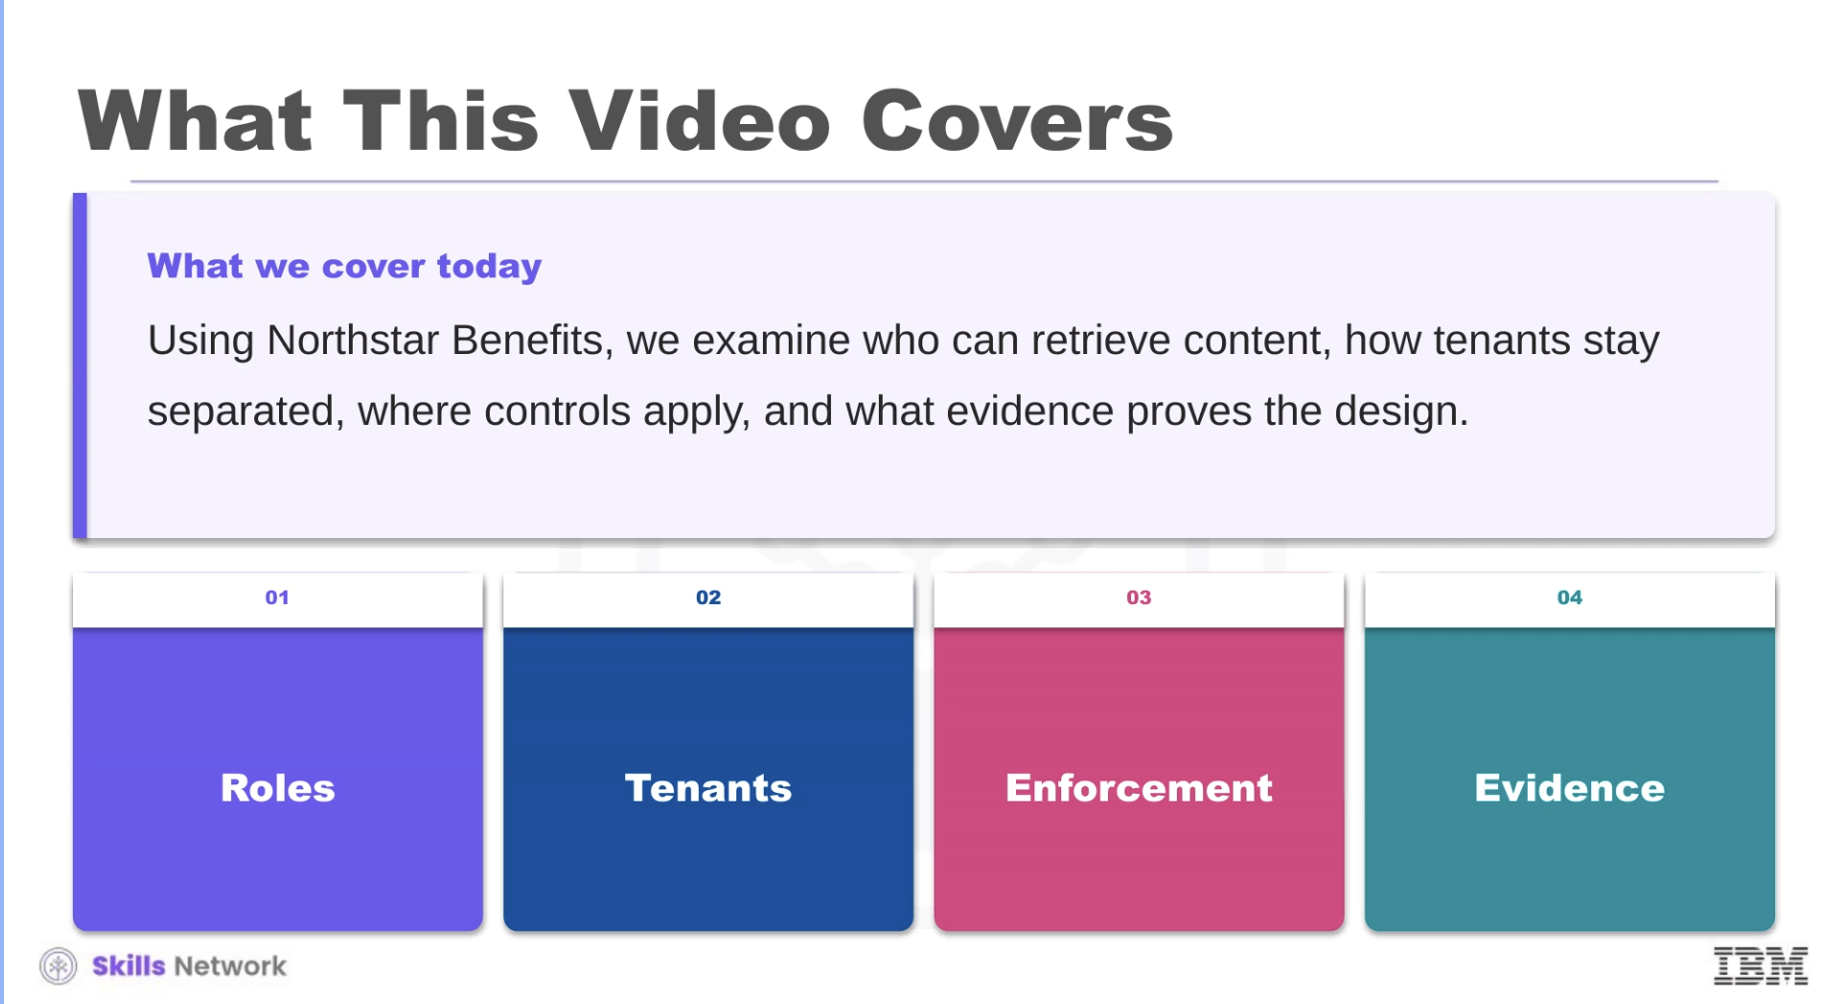
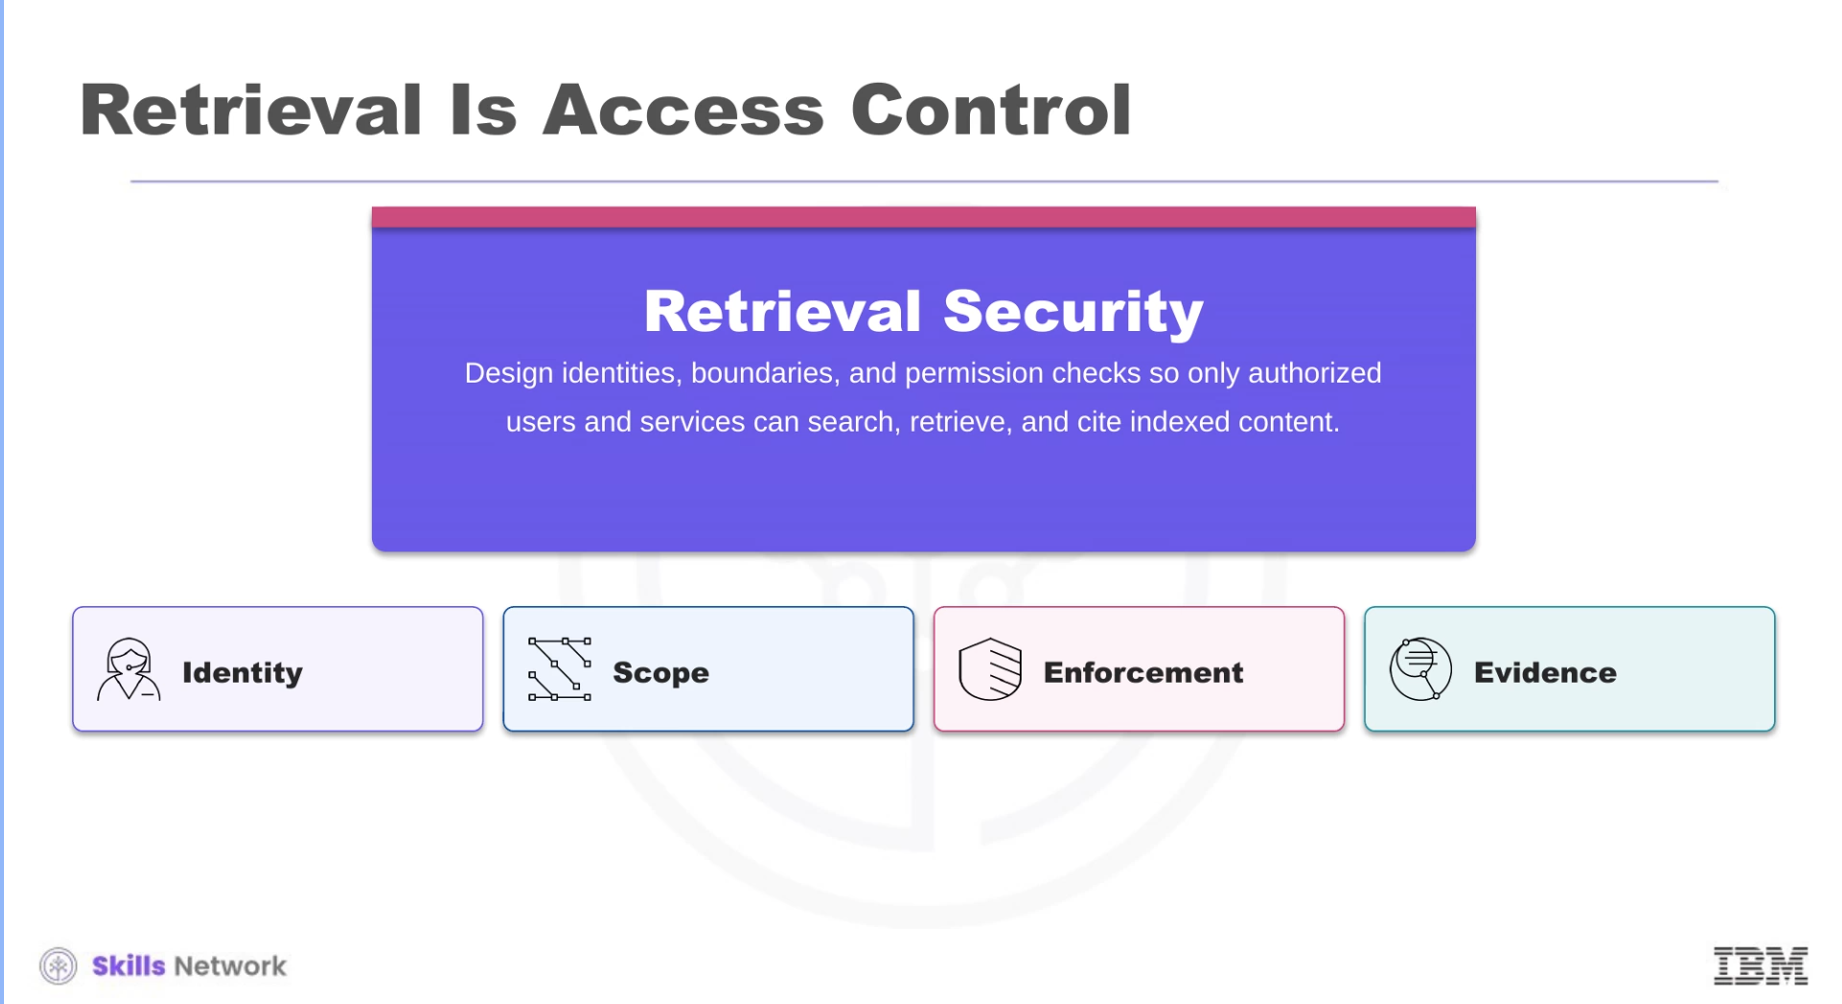
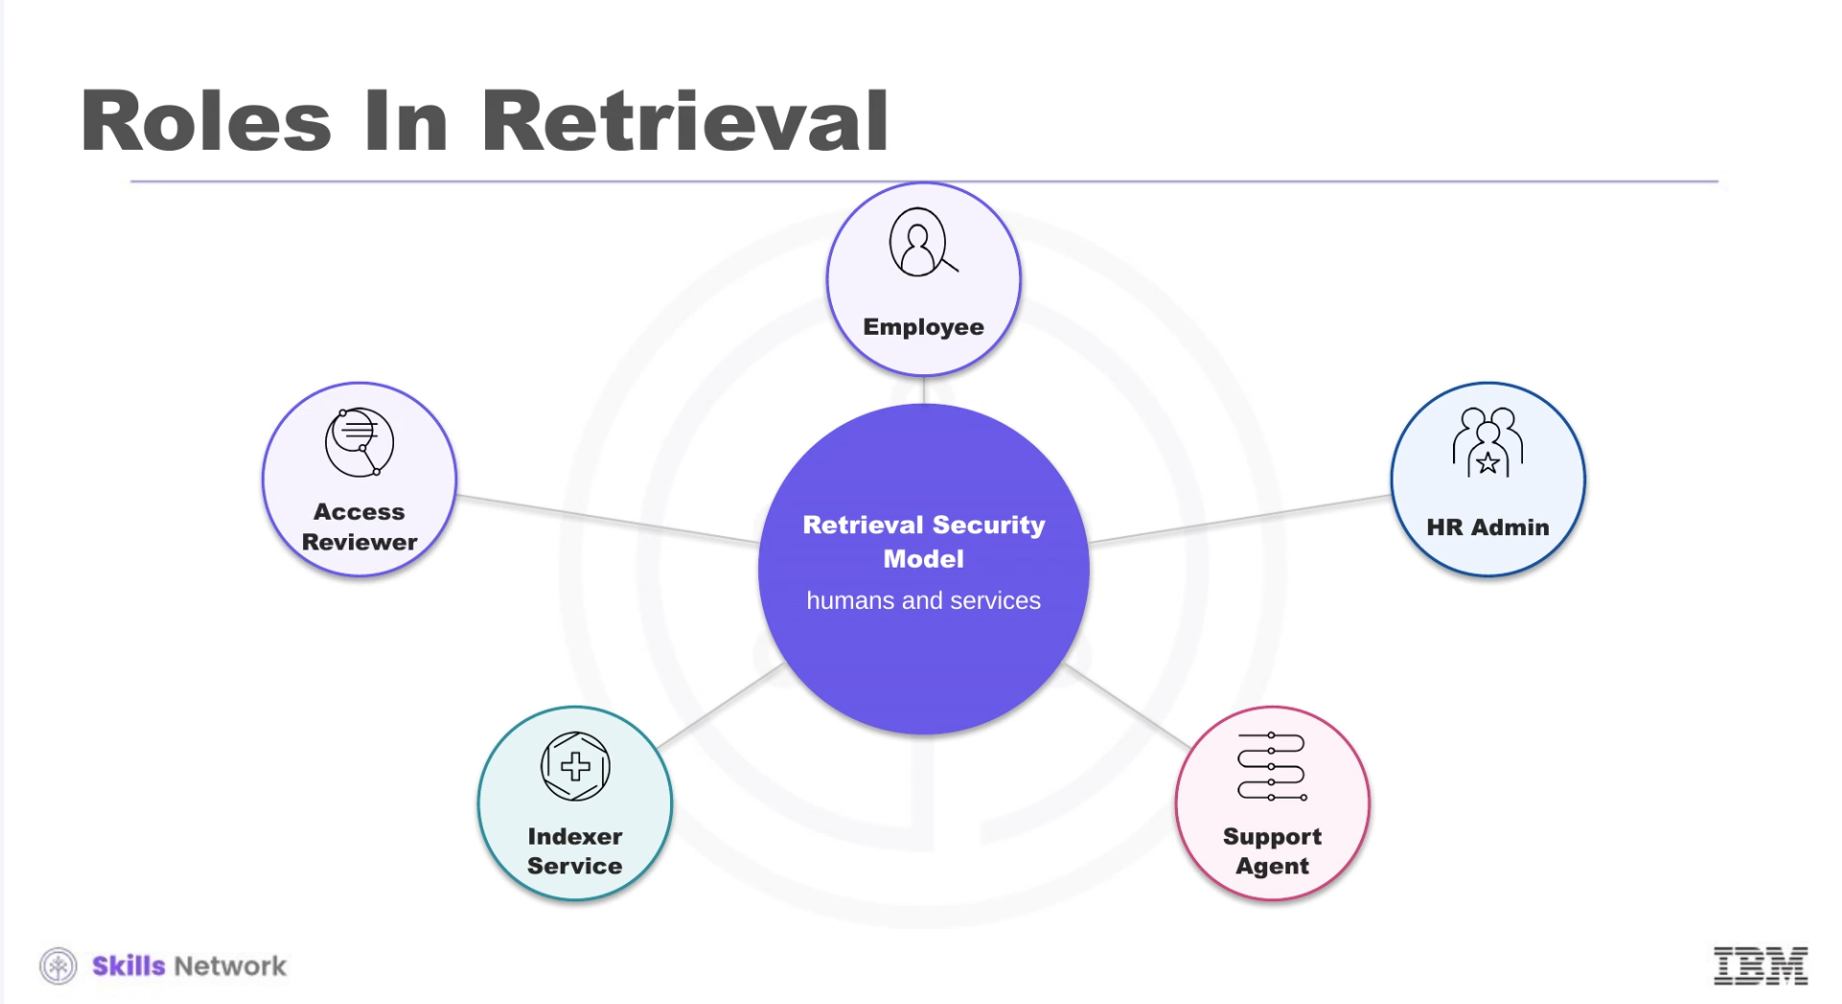
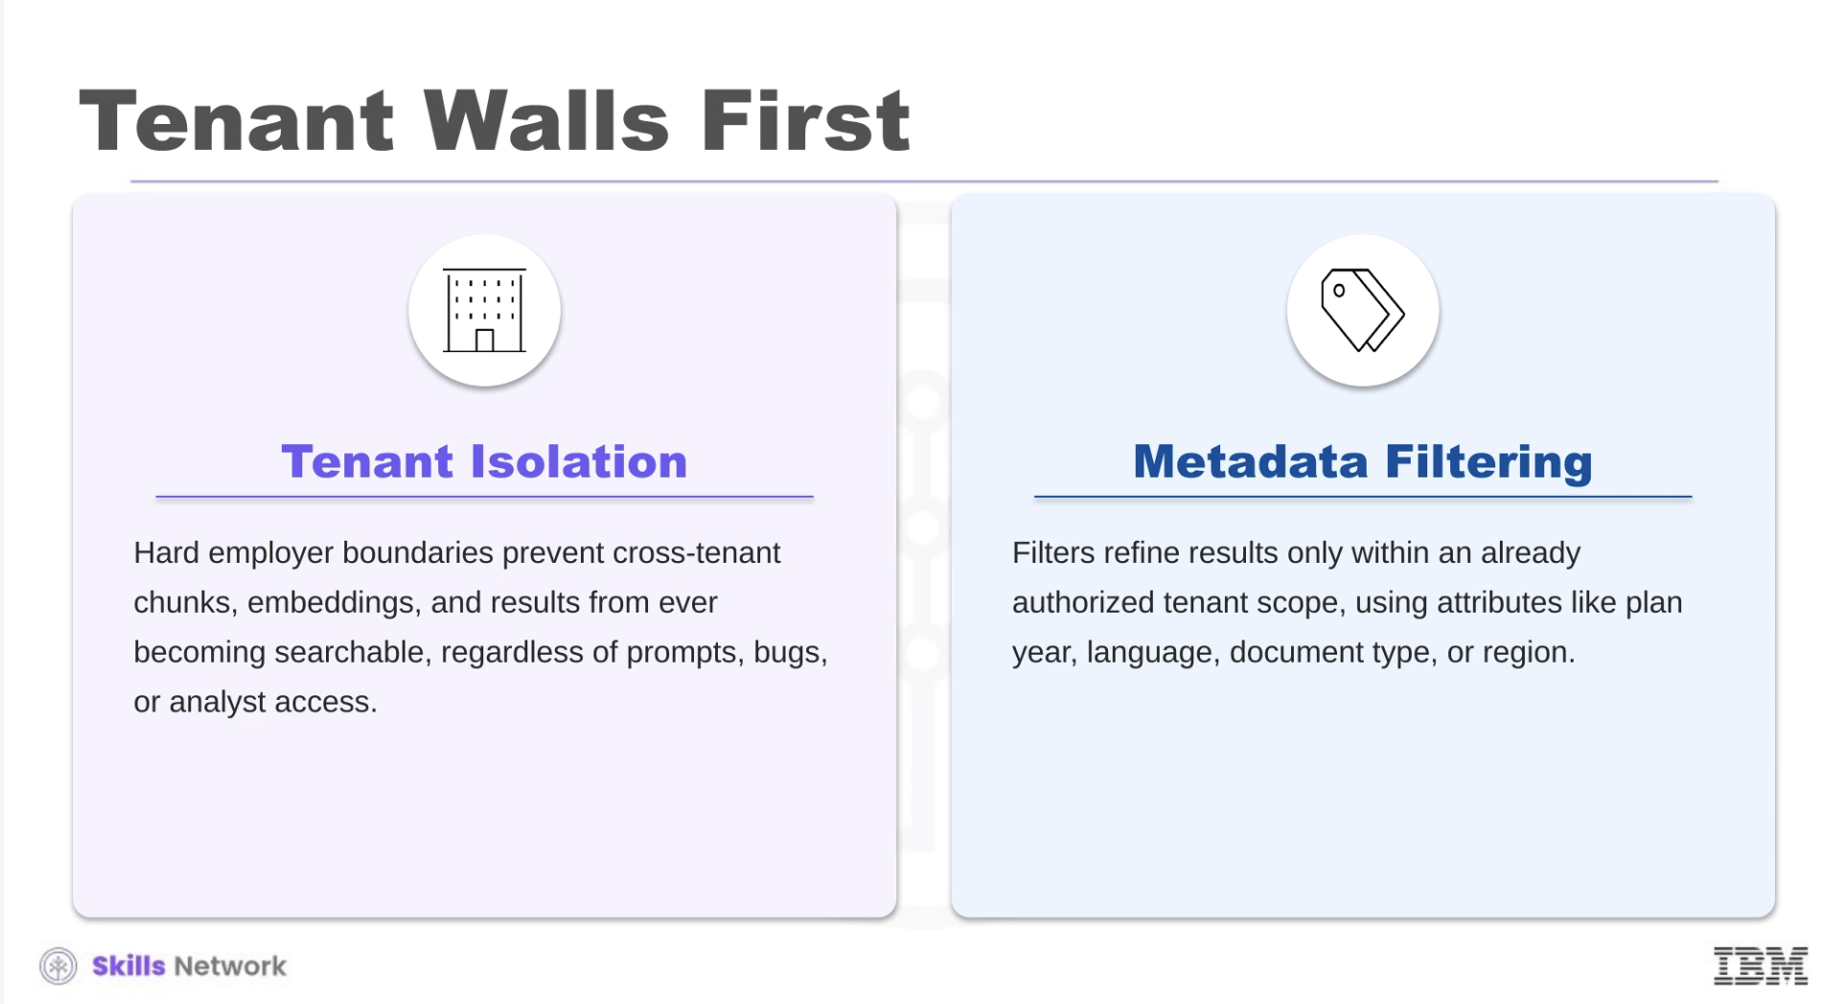
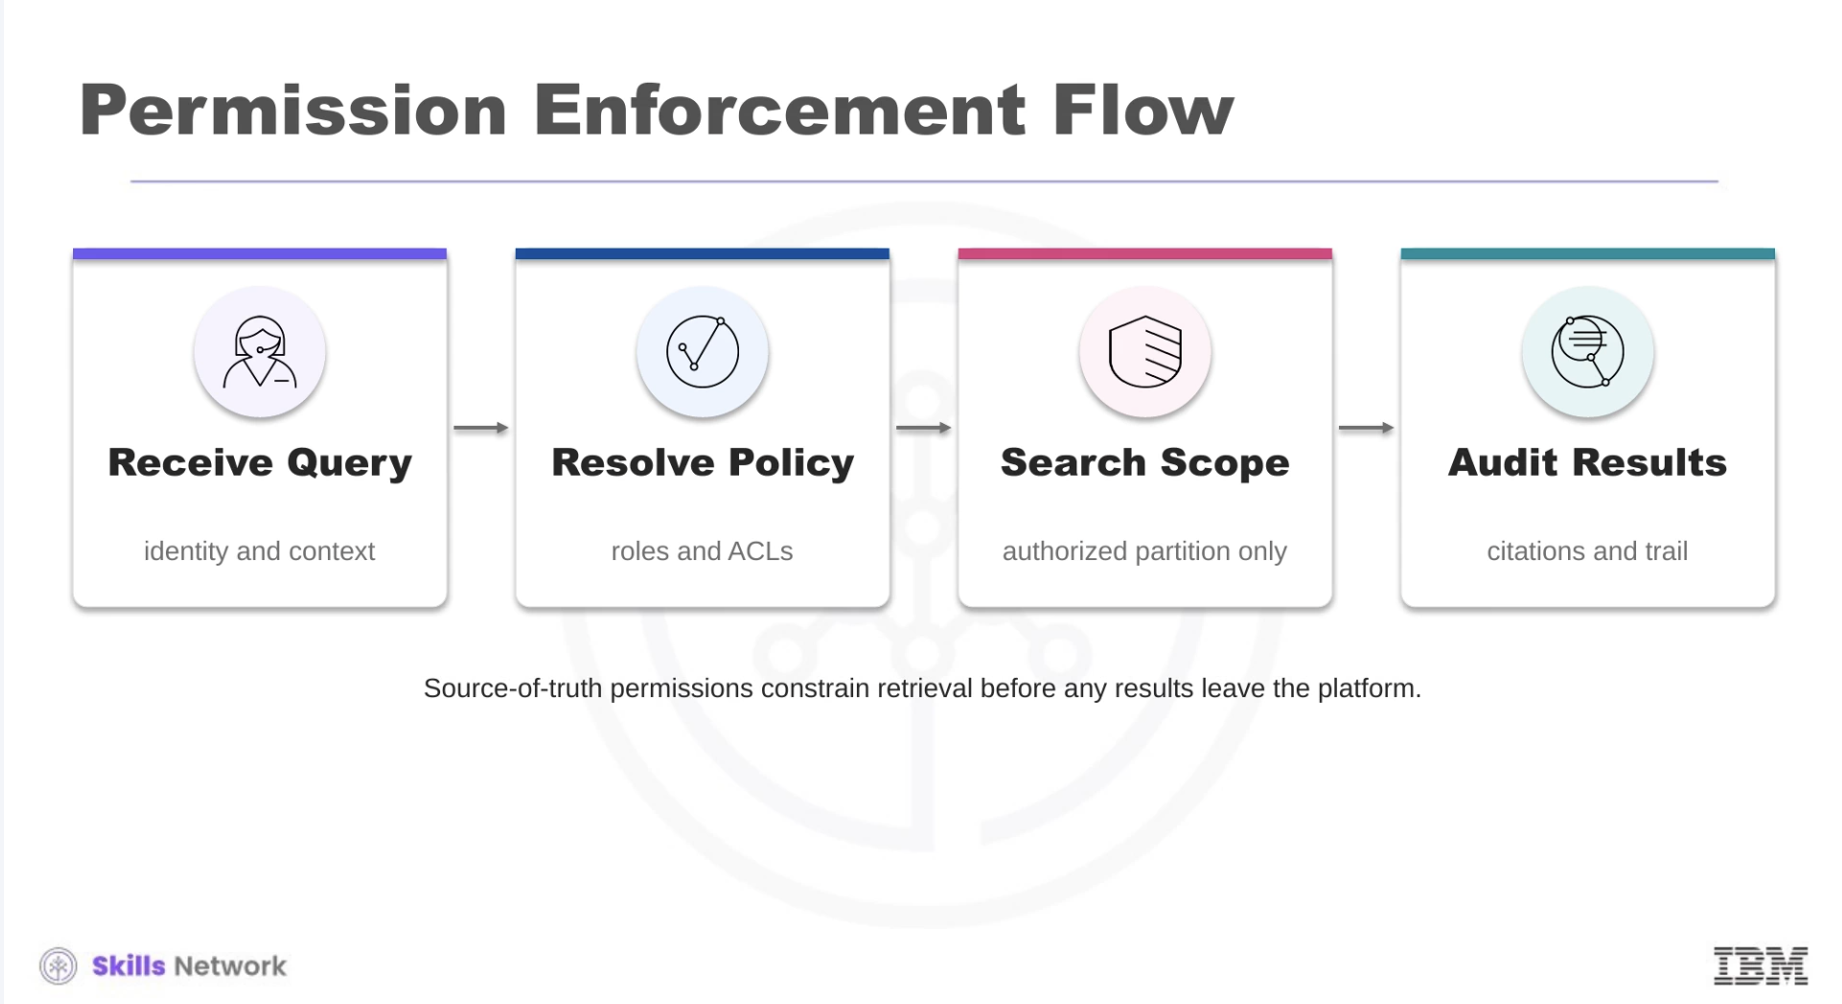
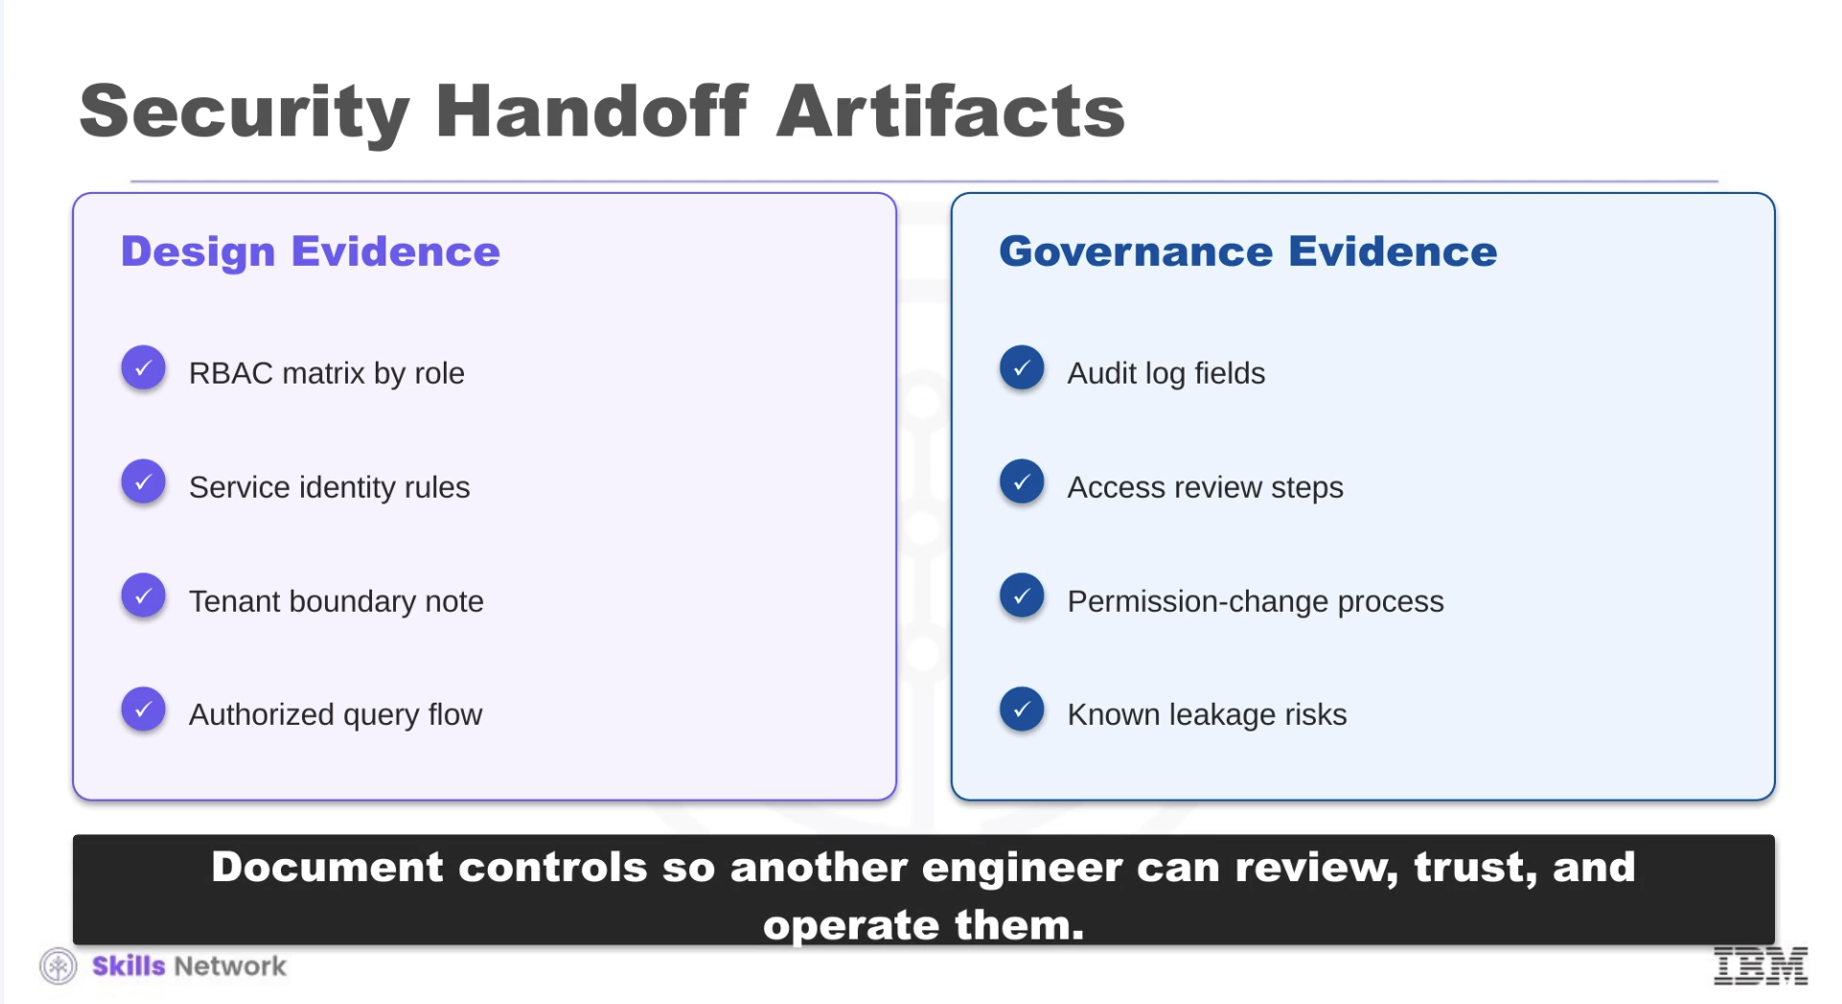



# 🔐 Permission-Aware Retrieval: RBAC, Tenant Isolation & Secure RAG

We already know RAG retrieval. Now we're adding the question:

> **"Even if this chunk is relevant, is this user actually allowed to receive it?"**

The chapter's central rule is:

> 📌 **Relevance gets you candidate results; policy decides what survives.**

---

## 1. RBAC in Retrieval

I already know RBAC conceptually: **Role-Based Access Control**.

Instead of saying:

```
User A → permission X
User B → permission Y
User C → permission Z
```

you define roles:

```
User → Role → Permissions
```

But here's the important part for RAG: **there aren't just users.** The retrieval system may have:

- users
- embedding pipelines
- ingestion workers
- reindex jobs
- support tools
- auditors
- reviewers
- admin accounts
- break-glass accounts

The course's warning is essentially:

> ⚠️ Don't give all of these one giant `can_query_everything` identity.

For example:

```
Embedding Pipeline
    ↓
Can:
  write vectors
  update metadata

Cannot:
  search every tenant
  read raw documents
  manage policies
```

That's **least privilege**. If that service account gets compromised, the **blast radius** is much smaller.

### Mental model

```
Identity
   ↓
Role
   ↓
Allowed capabilities
```

Not:

```
Every service → full database access
```

---

## 2. Tenant Isolation = HARD boundary

This is extremely important in enterprise RAG. Imagine the vector database contains:

```
Tenant A
├── HR docs
├── contracts
└── tickets

Tenant B
├── HR docs
├── contracts
└── tickets
```

A query from Tenant A must **never** retrieve Tenant B's documents. That's **tenant isolation**.

The course calls it a **hard boundary** because cross-tenant retrieval isn't merely a bad search result — it can become a **trust, contractual, or regulatory incident**.

### Three common ways to achieve it

#### Option 1 — Separate index/collection per tenant

```
Vector DB

Tenant A → Collection A
Tenant B → Collection B
Tenant C → Collection C
```

- **Advantage:** Very strong logical boundary.
- **Disadvantage:** Lots of tenants → lots of infrastructure/management.

#### Option 2 — Tenant partitions

```
Shared Vector DB

Partition A → Tenant A
Partition B → Tenant B
Partition C → Tenant C
```

More consolidated. But the partition enforcement has to be reliable.

#### Option 3 — Metadata filtering

Every chunk contains `tenant_id`. Then:

```
query
 ↓
tenant_id = tenant_A
 ↓
vector search
```

This is flexible and cheaper operationally.

**BUT: the filter must be enforced server-side.** The client shouldn't be able to say:

```json
{
    "tenant_id": "tenant_B"
}
```

and magically access B.

> 💡 The retrieval service must determine the user's **actual** tenant and construct the filter itself.

| | Separate index | Partitions | Metadata filter |
|---|---|---|---|
| Boundary strength | Very strong (logical) | Depends on partition enforcement | Depends on server-side filter |
| Operational cost | High with many tenants | Medium (consolidated) | Low (flexible, cheaper) |
| Main risk | Infra/management sprawl | Unreliable partition enforcement | Client-controlled filter |

---

## 3. The really important distinction: Relevant ≠ Allowed

This is probably **the most important concept in this section**.

Suppose the user asks:

```
"What is the CEO compensation policy?"
```

Vector search finds `CEO Compensation.pdf` — semantic similarity: 🔥 extremely high.

But the user doesn't have permission to see it. Therefore:

| Check | Result |
|---|---|
| Relevant? | YES |
| Authorized? | NO |
| **Return it?** | **❌ NO** |

So a valid RAG result needs:

```
Relevant
    AND
Correct tenant
    AND
Authorized
```

The course explicitly defines a good result as **similar + in-tenant + authorized under source-system rules**.

> 📌 This connects directly to the **SearchCare** case we just completed, where permission-aware failure jumped from **0.4% → 3.8%**.

---

## 4. Security metadata becomes part of the schema

This is where this chapter connects with our earlier vector schema design. Previously we said **metadata isn't just decoration**. Now we can see why.

The index may need fields such as:

```
tenant_id
document_id
source_system
owner_id
group_ids
entitlement_ids
classification
effective_from
effective_to
is_deleted
source_acl_version
```

These aren't random metadata fields. They are part of the **security contract** of the retrieval system.

| If this is wrong… | …then |
|---|---|
| `tenant_id` missing or wrong | tenant isolation breaks |
| `is_deleted` stale | deleted content can return |
| `source_acl_version` stale | old permissions can remain active |

> 💡 **Bad security metadata = potentially unsafe retrieval.**

---

## 5. The secure retrieval flow

This is the architecture I should remember.

```
User
  │
  │ query + identity
  ▼
Authentication
  │
  ▼
Identity Service
  │
  │ tenant
  │ groups
  │ entitlements
  ▼
Retrieval Service
  │
  │ builds SERVER-SIDE filters
  ▼
Vector DB
  │
  │ relevant candidates
  ▼
Permission Re-check
  │
  ├── ❌ Unauthorized → DENY / REDACT
  │
  └── ✅ Authorized
          │
          ▼
      LLM / User
```

The course specifically describes this sequence:

```
authenticate → resolve tenant/groups/entitlements → build server-side filters
→ search within allowed scope → re-check permissions → deny/redact failures
```

---

## 6. Why do we need TWO permission checks?

This is subtle but important. You might ask:

> "If we already filtered the vector search, why check again?"

Because **vector retrieval is optimized for retrieval, not authorization.**

```
Step 1:
Server-side filter says:
tenant = A
classification != restricted

        ↓

Vector search

        ↓

Candidate results
```

Something could still be wrong:

- stale metadata
- race condition
- ACL changed moments ago
- incorrect indexing
- filter bug

Therefore:

```
Pre-filter
    ↓
Vector search
    ↓
Final permission check
```

The course calls this a **double control**.

### Very important mental model

| | Pre-filter | Final check |
|---|---|---|
| When | Before vector search | After retrieval, before output |
| Purpose | Prevent obviously unauthorized content from **entering** the candidate set | Verify what is actually allowed to **leave** the system |

---

## 7. Never trust client-provided filters

Suppose the frontend sends:

```json
{
    "tenant_id": "tenant_42"
}
```

You shouldn't trust that, because a malicious user can change it to:

```json
{
    "tenant_id": "tenant_43"
}
```

The retrieval service should instead derive:

```
Authenticated identity
        ↓
Identity service
        ↓
Actual tenant = tenant_42
        ↓
Server constructs filter
```

The course explicitly says:

> 📌 **Client-provided filters are hints, never final authorization boundaries.**

That's a very important security principle.

---

## 8. Permission changes are a freshness problem

Here's a nasty production scenario:

```
10:03
User loses access to folder

10:04
Source system:
User is correctly denied

10:15
Vector DB:
Old ACL still present

        ↓

User queries RAG

        ↓

Old document retrieved
```

Nothing crashed. No API failure. No database outage. **But you have a permission leak.**

The course calls these **delayed permission failures** some of the ugliest retrieval leaks.

---

## 9. Therefore permission updates need their own pipeline

Possible mechanisms:

### Event-driven

```
Source ACL change
      ↓
Event
      ↓
Update vector metadata
```

### Scheduled sync

```
Every N minutes
      ↓
Check permission changes
      ↓
Patch metadata
```

### Metadata patch

Update existing chunks **without re-embedding**.

### Full reindex

Used when the permission model itself changes significantly.

### Query-time version check

Before returning a document:

```
source ACL version
        vs
indexed ACL version

If stale:
DENY
```

The course lists all of these as production mechanisms.

---

## 10. The security review checklist

This is worth remembering because it translates directly into architecture questions.

| Area | Question to ask | Notes |
|---|---|---|
| **Identity** | Who can query? | Users? Services? Admins? Batch jobs? Break-glass accounts? |
| **Metadata** | Which fields are security-critical? | `tenant_id`, groups, entitlements, classification, deletion state, ACL version, etc. |
| **Enforcement** | Where is authorization enforced? | Client? Application? Retrieval service? Database?<br>Client-controlled = 🚨 |
| **Propagation** | How quickly do permission changes reach retrieval? | |
| **Audit** | What happens when access is denied? | See log fields below |

**Audit — log:**

```
caller identity
tenant
query fingerprint
document/chunk ID
denial reason
timestamp
enforcement point
```

The chapter explicitly recommends logging these denial signals for investigation and detection.

---

## 11. Connect this to MY secure RAG idea

This is where things get interesting. I've been thinking about having:

```
User
 ↓
Main RAG / LLM
 ↓
Second security layer
```

This chapter tells us something important:

> ⚠️ **The security boundary should NOT depend solely on my second LLM.**

Authorization should be enforced **structurally**:

```
Identity
 ↓
Server-side authorization
 ↓
Metadata filtering
 ↓
Vector retrieval
 ↓
Permission re-check
 ↓
LLM
```

My "police officer" LLM can potentially be an **additional** reasoning/safety layer, but it should **not** be the thing deciding whether a user is allowed to access a document.

**Why?** Because authorization is **deterministic policy enforcement**.

You don't want:

```
LLM:
"I think this document is probably okay."
```

You want:

```
Policy:
tenant_id == user's tenant
AND
user ∈ authorized_groups
AND
is_deleted == false
AND
classification permitted
```

> 💡 That distinction is huge for the architecture we'll eventually build.

---

## 12. The entire section in one picture

```
                 USER
                   │
                   ▼
            Authentication
                   │
                   ▼
          Identity / RBAC
                   │
          ┌────────┴────────┐
          │                 │
       Tenant            Permissions
          │                 │
          └────────┬────────┘
                   ▼
          SERVER-SIDE FILTER
                   │
                   ▼
              VECTOR DB
                   │
                   ▼
          Relevant candidates
                   │
                   ▼
        FINAL POLICY CHECK
           │             │
       Allowed         Denied
           │             │
           ▼             ▼
          LLM         Log / Reject
           │
           ▼
        RESPONSE
```

---

## 🎯 Priorities

### 🔴 Must know

- RBAC applies to users **AND** service identities.
- Tenant isolation is a **hard boundary**.
- Separate indexes, partitions, or metadata filters are possible isolation patterns.
- Client filters cannot be trusted.
- Authorization must be enforced **server-side**.
- **Relevant ≠ authorized.**
- Security metadata is part of the schema.
- Use **pre-filter + final permission check**.
- Permission changes need fast propagation.
- Denials need to be logged and auditable.

### 🟡 Conceptual

- Separate index vs partition vs metadata-filter tradeoffs.
- ACL versioning.
- Query-time version checks.
- Break-glass accounts.

### 🟢 Don't memorize

- The exact JSON filter syntax.
- Vendor-specific implementation.
- Every possible propagation mechanism.

---

## 🔒 The one sentence to lock in

> 📌 **Vector search finds what is relevant; the authorization layer decides what the user is allowed to see.**

This is a core piece of the architecture we're eventually going to implement in the final project.

 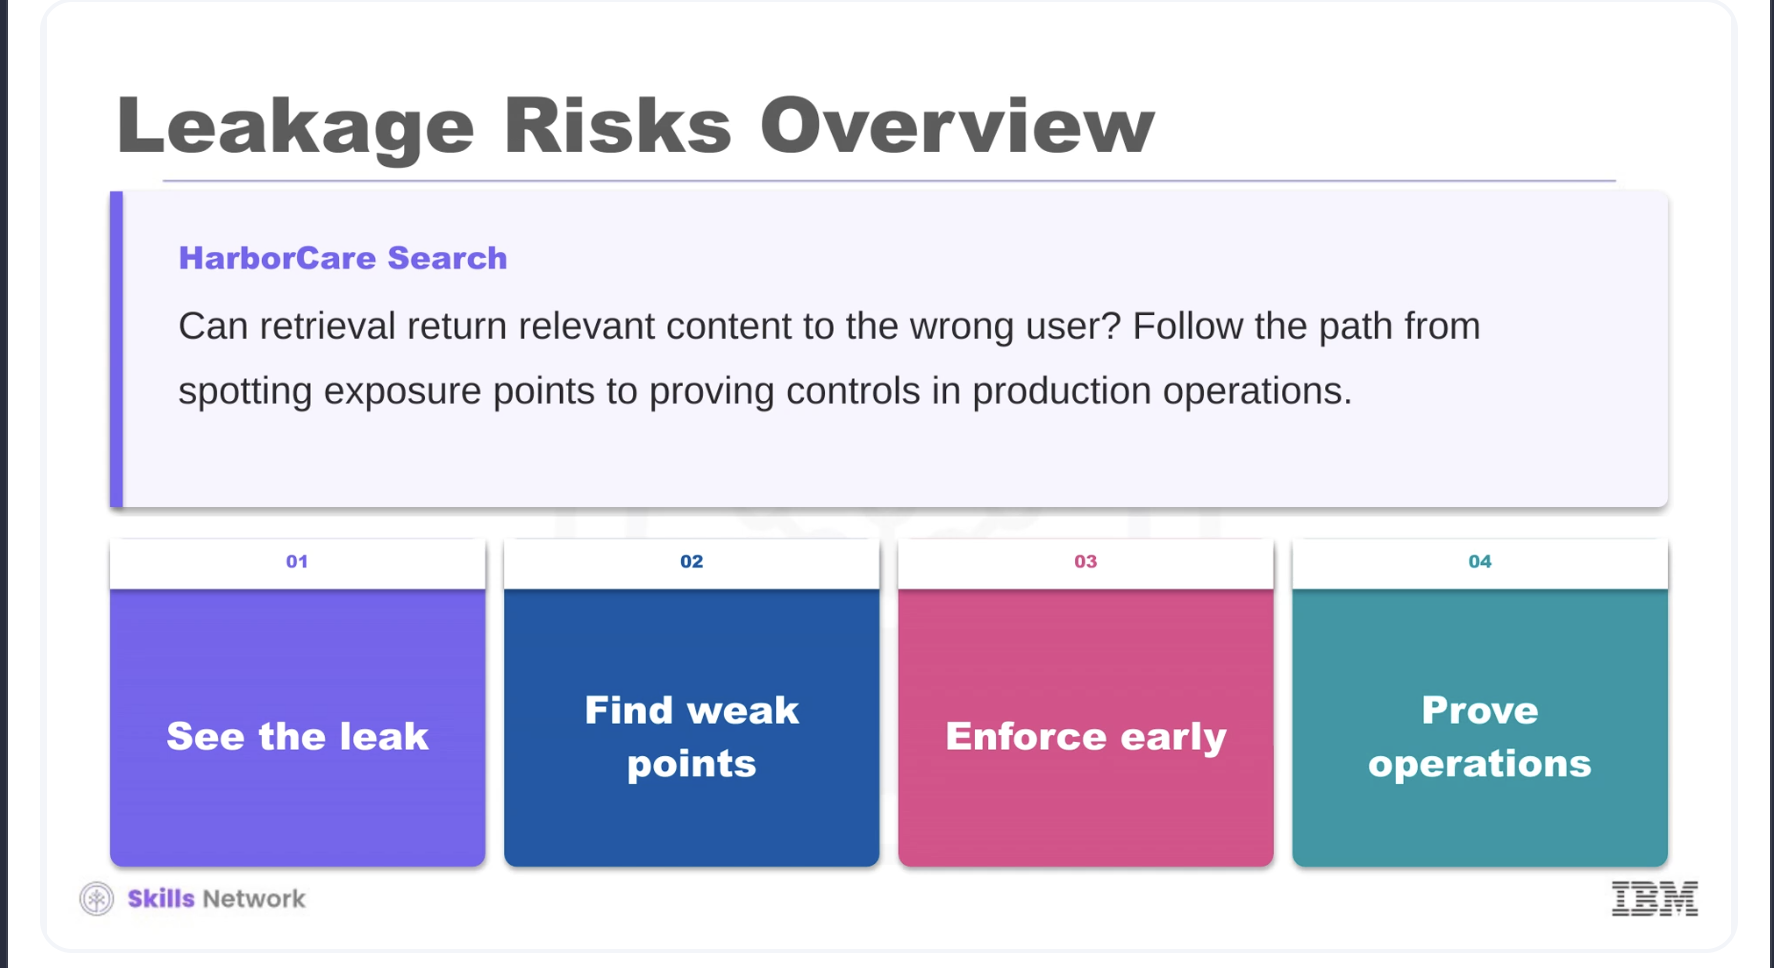
 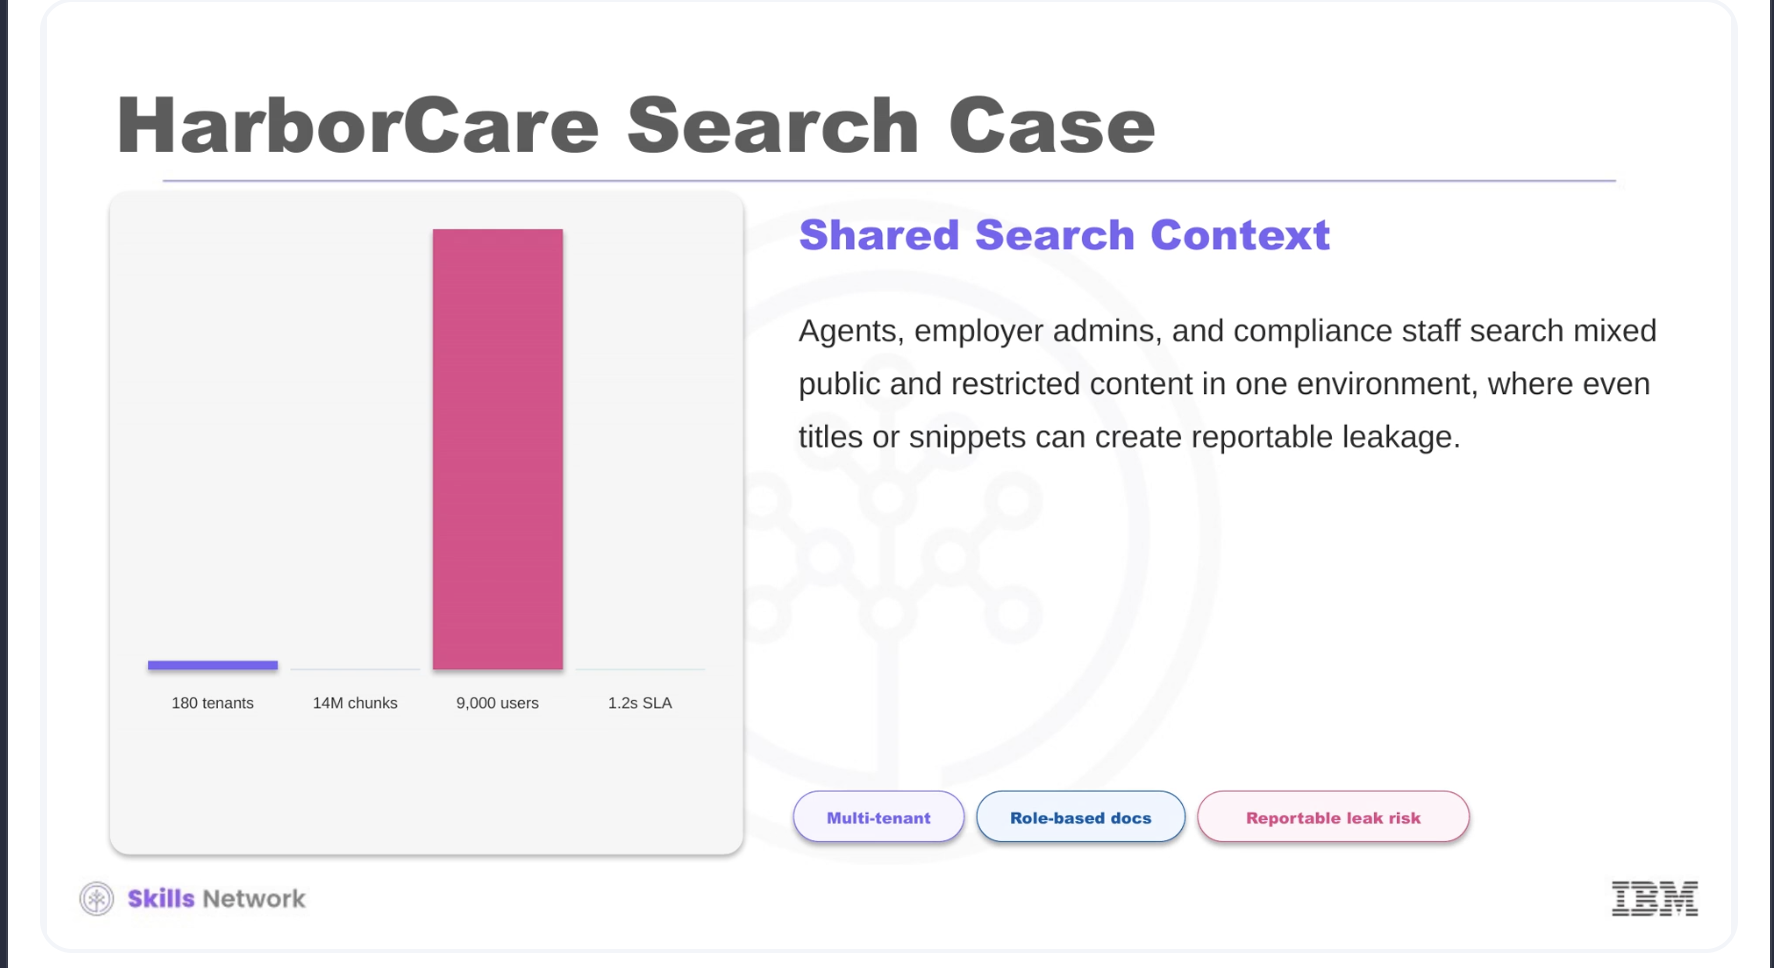
 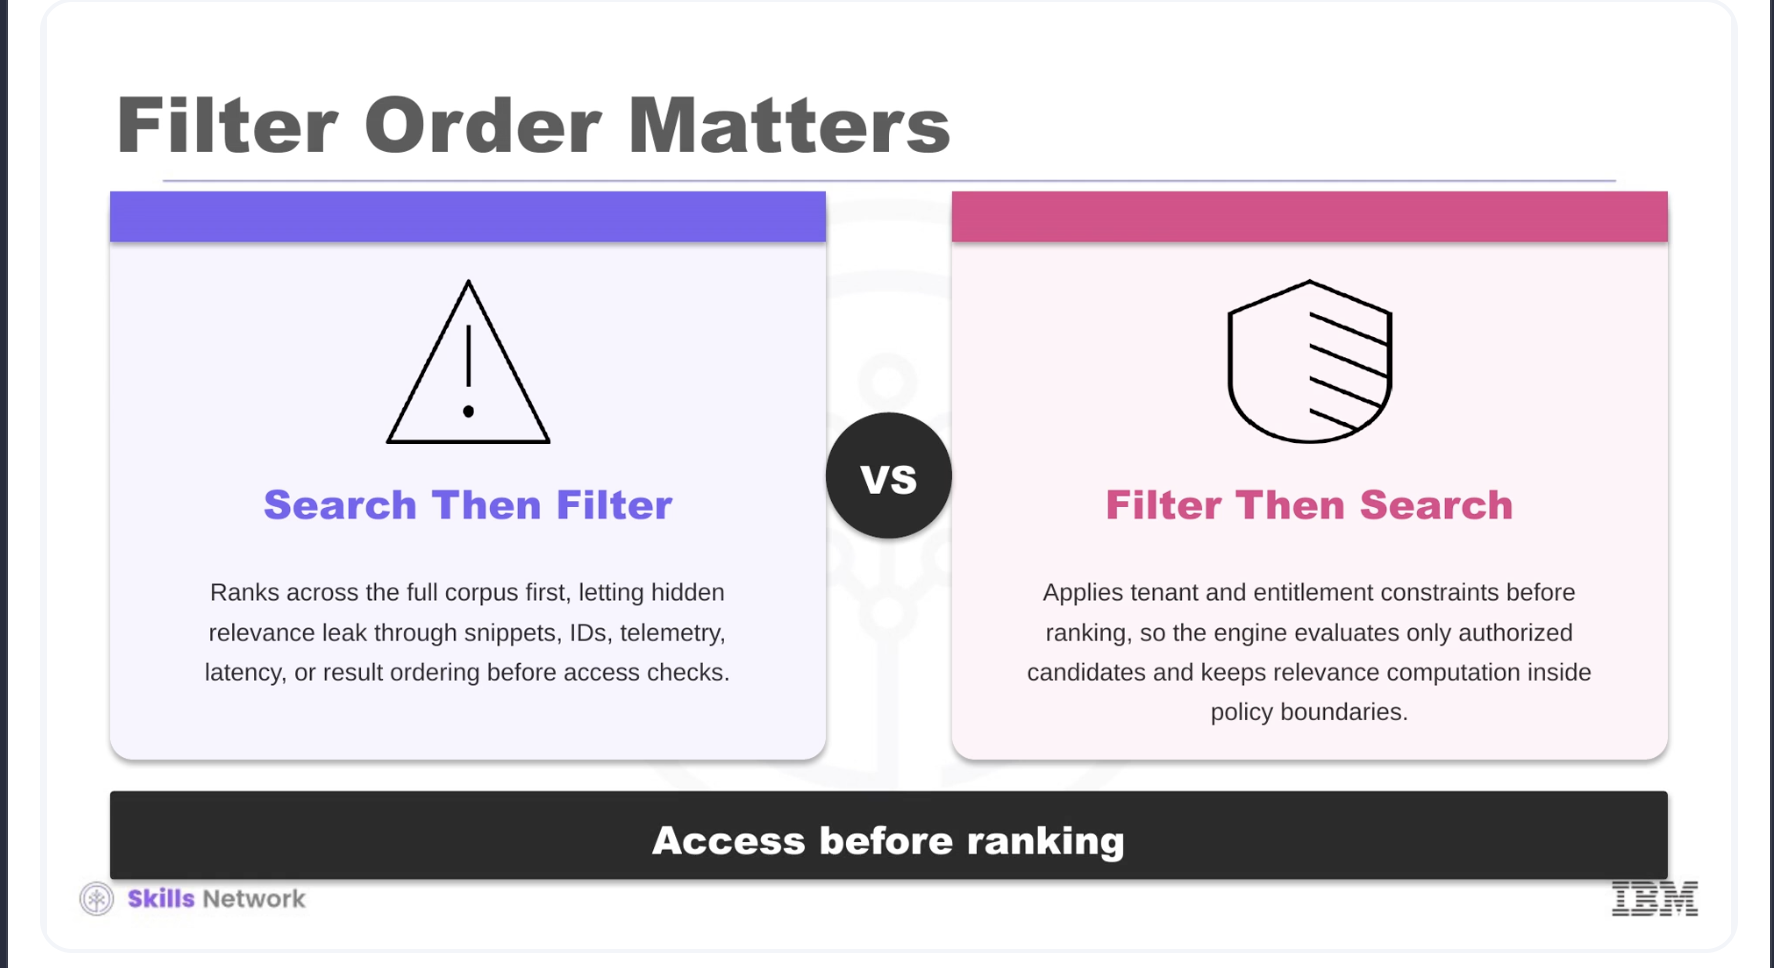
 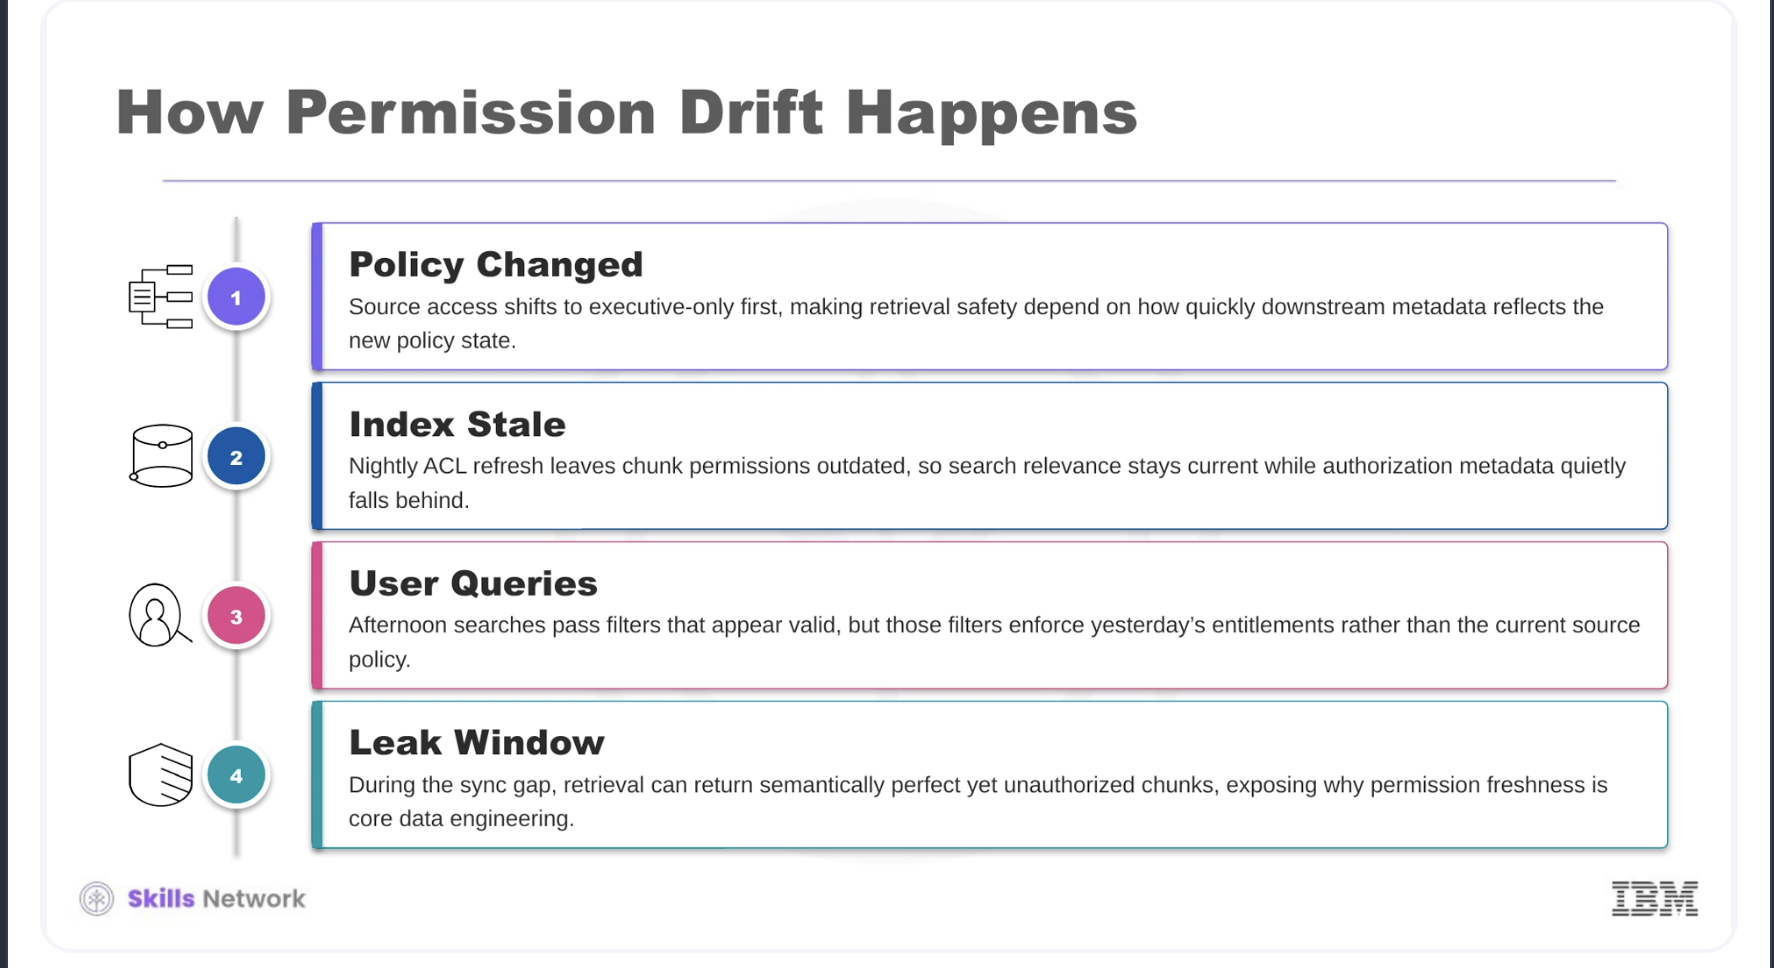
 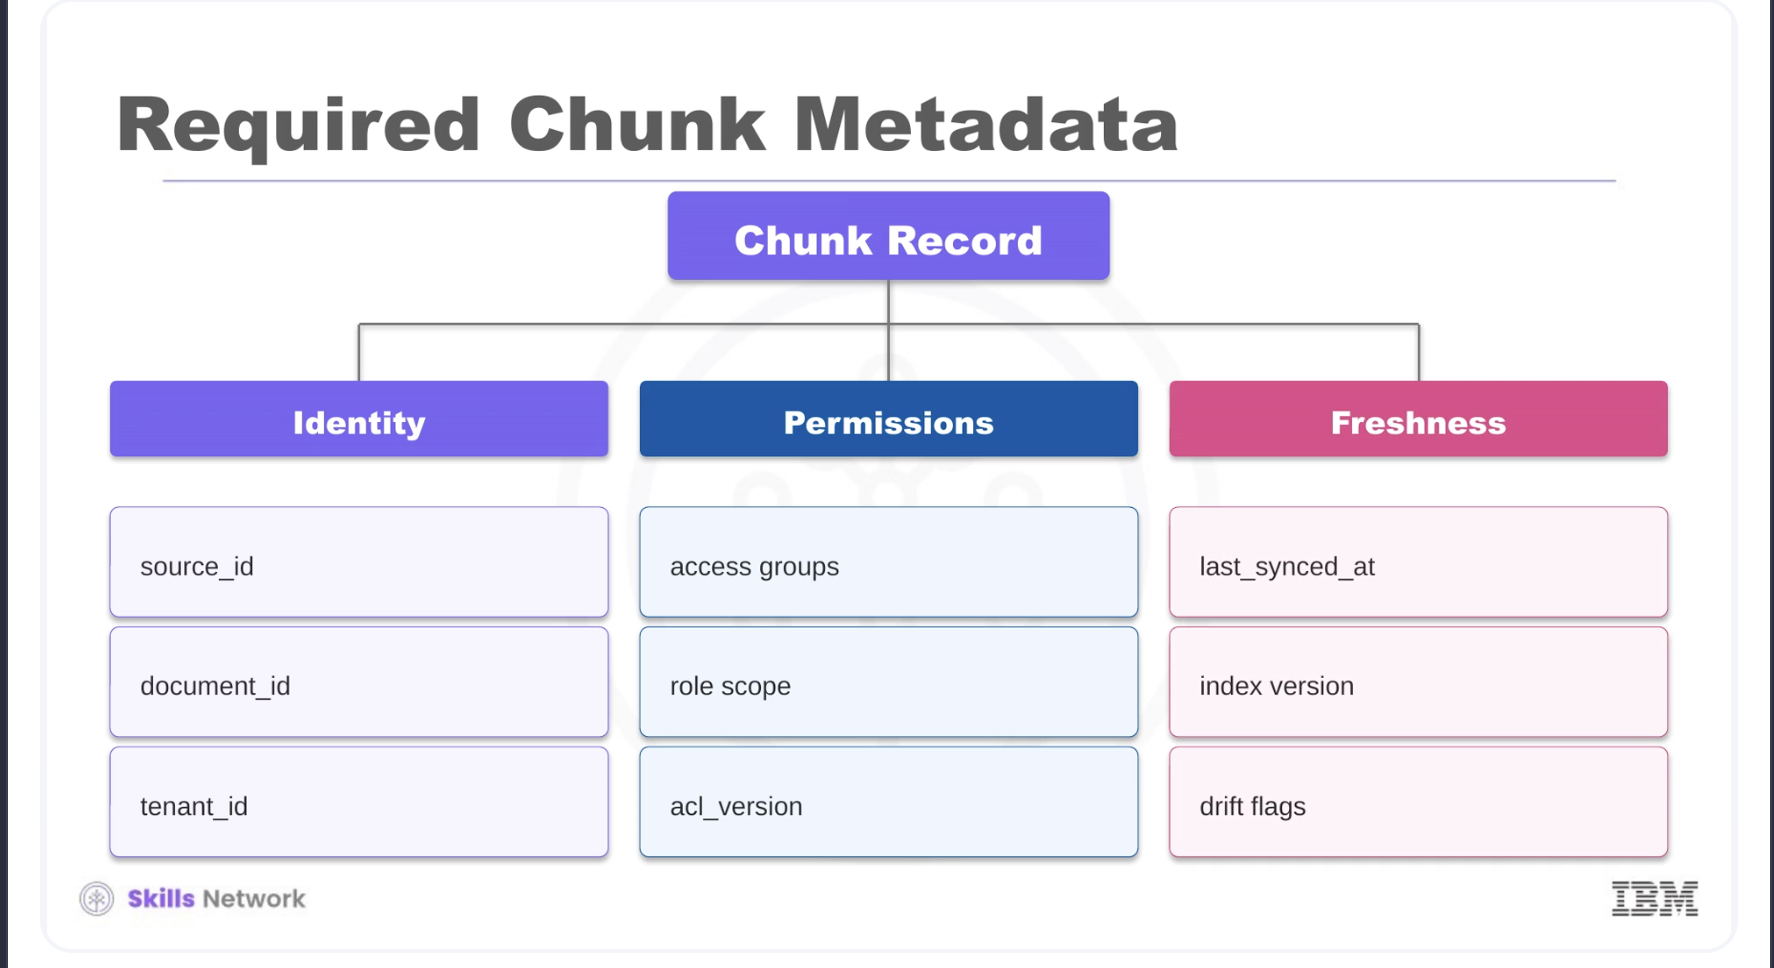
 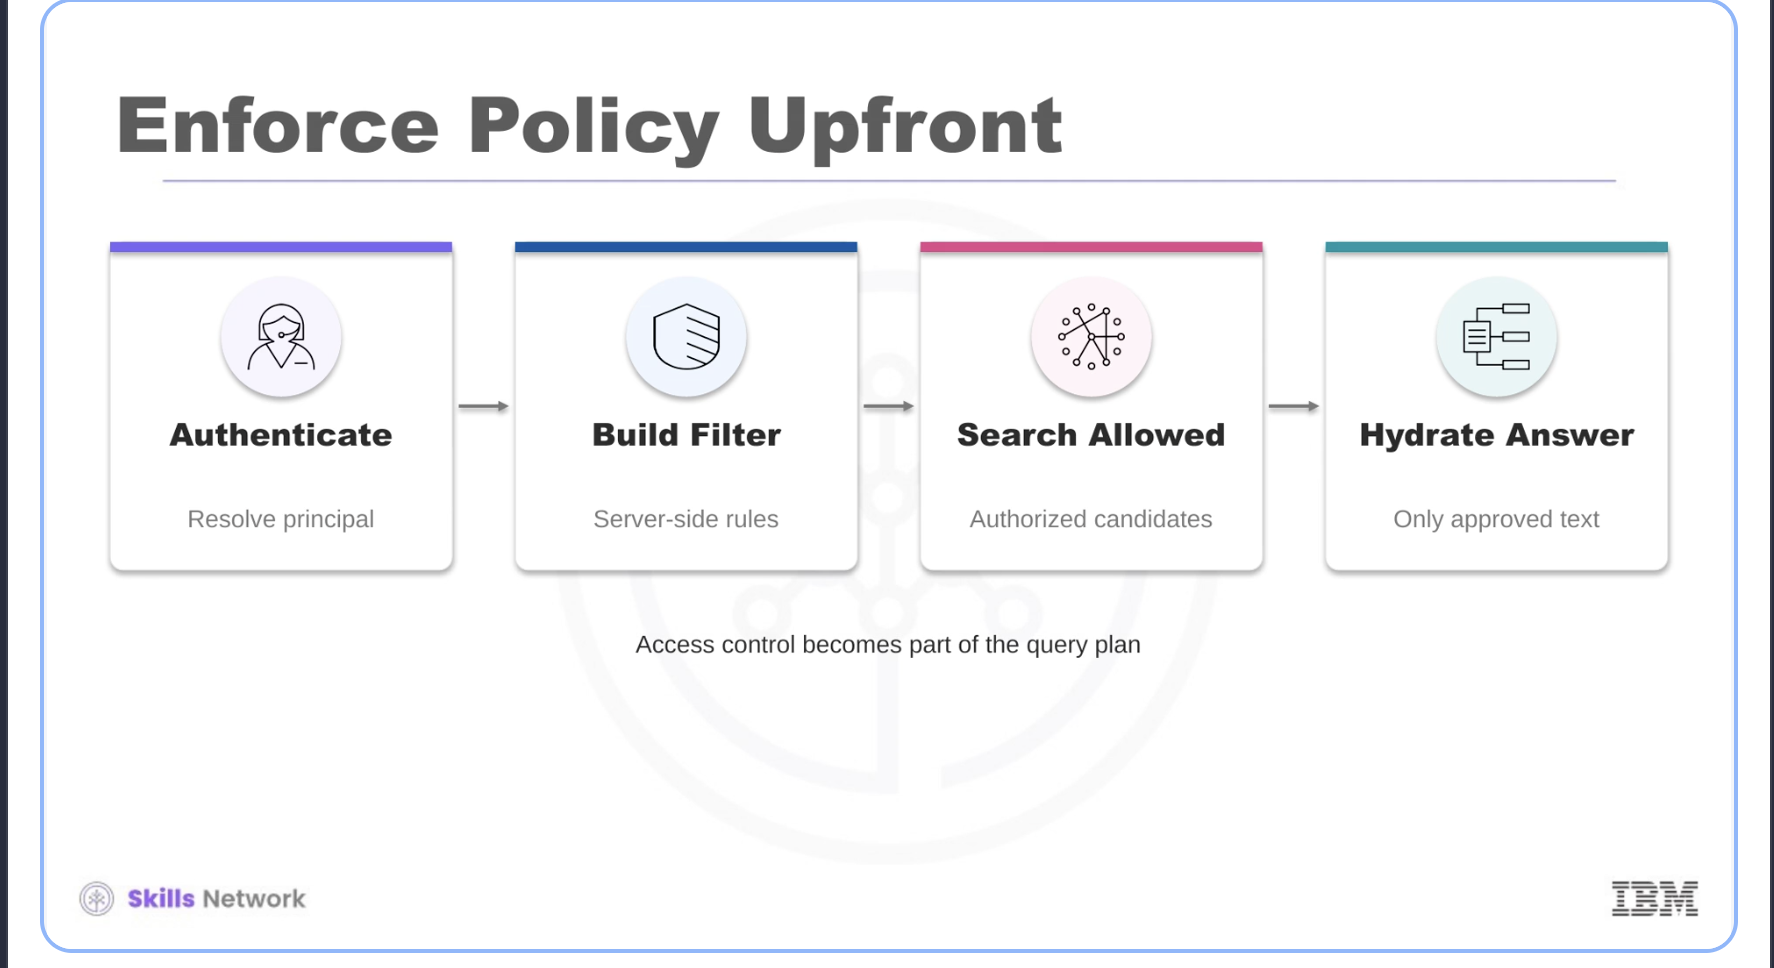
 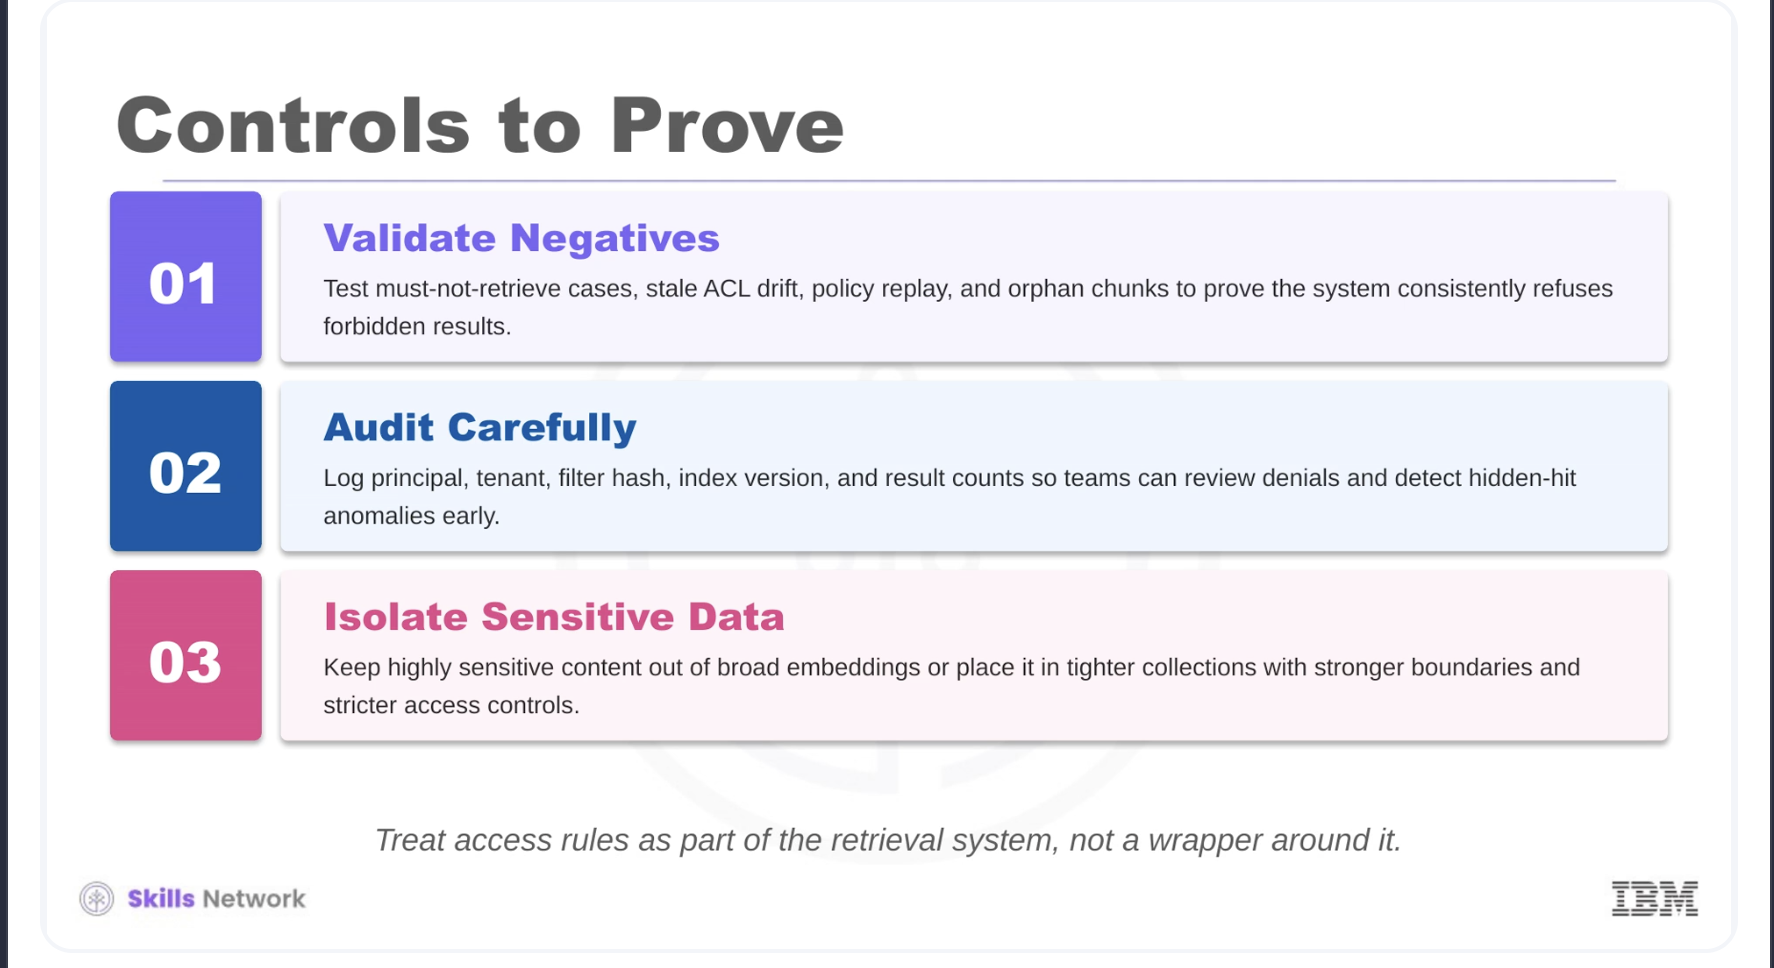